In [53]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        #print(os.path.join(dirname, filename))
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [54]:
# Cell 1: Install dependencies (run once)
!pip install -q timm==0.9.2

# Imports
import os
import glob
import random
from pathlib import Path
from pprint import pprint
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from torch.optim import Adam
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
# ADD INSTALLATION for smp
!pip install -q segmentation-models-pytorch
import segmentation_models_pytorch as smp
# ... existing code ...

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("timm version:", timm.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
Device: cuda
timm version: 0.9.2


In [55]:
# Cell 2: Configuration (edit paths / params)
INPUT_SIZE = 256 # image H/W
BATCH_SIZE = 8   # reduce if memory limited
NUM_WORKERS = 0
NUM_CLASSES = 1
EPOCHS = 50      # Increased max epochs to allow early stopping to kick in
LR = 5e-5        # Reduced Learning Rate (Hyperparameter Tuning)
SEED = 42

PATIENCE = 10     # Early Stopping Patience: Stop if no improvement after N epochs
WEIGHT_DECAY = 1e-5 # L2 Regularization (Hyperparameter Tuning)

FRAMES_DIR = "/kaggle/input/covid19-ct-scan-lesion-segmentation-dataset/frames"
MASKS_DIR  = "/kaggle/input/covid19-ct-scan-lesion-segmentation-dataset/masks"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Utility: list files
frames = sorted(glob.glob(os.path.join(FRAMES_DIR, "*.png")))
masks  = sorted(glob.glob(os.path.join(MASKS_DIR,  "*.png")))
assert len(frames) == len(masks) and len(frames) > 0, "Files missing or mismatch!"
print("Total samples:", len(frames))

Total samples: 2729


In [56]:
# Cell 3: Dataset and augmentations

# Custom dataset
class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform_img, transform_mask):
        self.images = image_paths
        self.masks = mask_paths
        self.transform_img = transform_img
        self.transform_mask = transform_mask

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        msk = Image.open(self.masks[idx]).convert("L")
        img = self.transform_img(img)
        msk = self.transform_mask(msk)
        msk = (msk > 0.5).float()  # ensure binary
        return img, msk

# --- Define transforms ---
img_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
])
mask_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=Image.NEAREST),
    transforms.ToTensor(),
])

# --- Split train/val/test ---
# First split: 80% train+val, 20% test
train_val_imgs, test_imgs, train_val_masks, test_masks = train_test_split(
    frames, masks, test_size=0.2, random_state=SEED
)
# Second split: 80% train, 20% val (from train_val set)
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_val_imgs, train_val_masks, test_size=0.25, random_state=SEED # 0.25 of 80% is 20% of total
)

# --- Create datasets ---
train_ds = SegmentationDataset(train_imgs, train_masks, img_transform, mask_transform)
val_ds   = SegmentationDataset(val_imgs, val_masks, img_transform, mask_transform)
test_ds  = SegmentationDataset(test_imgs, test_masks, img_transform, mask_transform)

# --- Corresponding dataloaders ---
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}, Test samples: {len(test_ds)}")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train samples: 1637, Val samples: 546, Test samples: 546
Train batches: 205
Validation batches: 69
Test batches: 69


In [57]:
# Cell 4: Loss & metrics
def dice_coef_tensor(y_true, y_pred, smooth=1e-6):
    y_true = y_true.float()
    y_pred = y_pred.float()
    inter = (y_true * y_pred).sum(dim=(1,2,3))
    denom = y_true.sum(dim=(1,2,3)) + y_pred.sum(dim=(1,2,3))
    dice = (2.0 * inter + smooth) / (denom + smooth)
    return dice.mean()

def iou_tensor(y_true, y_pred, smooth=1e-6):
    y_true = y_true.float()
    y_pred = y_pred.float()
    inter = (y_true * y_pred).sum(dim=(1,2,3))
    union = y_true.sum(dim=(1,2,3)) + y_pred.sum(dim=(1,2,3)) - inter
    iou = (inter + smooth) / (union + smooth)
    return iou.mean()

def sensitivity_tensor(y_true, y_pred):
    y_true = y_true.float()
    y_pred = (y_pred > 0.5).float()
    tp = (y_true * y_pred).sum(dim=(1,2,3))
    pos = y_true.sum(dim=(1,2,3))
    return (tp / (pos + 1e-6)).mean()

def specificity_tensor(y_true, y_pred):
    y_true = y_true.float()
    y_pred = (y_pred > 0.5).float()
    tn = ((1 - y_true) * (1 - y_pred)).sum(dim=(1,2,3))
    neg = (1 - y_true).sum(dim=(1,2,3))
    return (tn / (neg + 1e-6)).mean()

# Loss Function: Hybrid BCE + Dice Loss (using smp for clean implementation)
# We set alpha=0.5 to keep the 50/50 weighting you used previously.
class HybridLoss(nn.Module):
    def __init__(self, alpha=0.5, from_logits=True):
        super().__init__()
        self.alpha = alpha
        self.bce_loss = nn.BCEWithLogitsLoss()
        # smp.losses.DiceLoss is already (1 - Dice Coefficient)
        self.dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=from_logits)

    def forward(self, y_pred, y_true):
        bce = self.bce_loss(y_pred, y_true)
        dice = self.dice_loss(y_pred, y_true)
        return self.alpha * bce + (1 - self.alpha) * dice

# Instantiate the criterion object
criterion = HybridLoss(alpha=0.5).to(device)

In [58]:
# Cell 5: Decoder blocks (shared by both models)
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    def forward(self, x, skip):
        x = self.up(x)
        # center-crop/pad skip to match x if needed
        if skip is not None and skip.shape[-2:] != x.shape[-2:]:
            skip = F.interpolate(skip, size=x.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1) if skip is not None else x
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return x

In [59]:
# Cell 6: TransUNet (lightweight)
class TransUNetLite(nn.Module):
    def __init__(self, backbone_name="resnet34", pretrained=True, num_classes=1, embed_dim=512, num_heads=8, transformer_layers=2):
        super().__init__()
        # use timm features_only to get multi-scale features
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, features_only=True, out_indices=(0,1,2,3))
        feats = self.backbone.feature_info.channels()  # list of channels for each feature map
        c1, c2, c3, c4 = feats  # low→high
        # Project deepest feature to embed_dim for transformer
        self.project = nn.Conv2d(c4, embed_dim, kernel_size=1)
        # simple transformer encoder on flattened patches of deepest features
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=embed_dim*2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)
        # decoder blocks: we will decode from embed_dim -> c3 -> c2 -> c1
        self.dec3 = DecoderBlock(in_channels=embed_dim, skip_channels=c3, out_channels=256)
        self.dec2 = DecoderBlock(in_channels=256, skip_channels=c2, out_channels=128)
        self.dec1 = DecoderBlock(in_channels=128, skip_channels=c1, out_channels=64)
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # backbone features: list [f1,f2,f3,f4] where f4 is deepest
        feats = self.backbone(x)
        f1, f2, f3, f4 = feats
        # project
        p = self.project(f4)                       # shape [B, E, Hf, Wf]
        B, E, Hf, Wf = p.shape
        # flatten patches for transformer: seq_len = Hf*Wf
        seq = p.flatten(2).transpose(1,2)          # [B, seq, E]
        seq = self.transformer(seq)                # [B, seq, E]
        # reshape back
        p2 = seq.transpose(1,2).view(B, E, Hf, Wf)  # [B, E, Hf, Wf]
        # decode
        d3 = self.dec3(p2, f3)                     # up -> combine with f3
        d2 = self.dec2(d3, f2)
        d1 = self.dec1(d2, f1)
        out = self.final_conv(d1)
        out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)
        return out

# sanity instantiate
_model = TransUNetLite(pretrained=True).to(device)
print("TransUNetLite parameters:", sum(p.numel() for p in _model.parameters())/1e6, "M")

TransUNetLite parameters: 15.238145 M


In [60]:
# Cell 8: Training utilities and run

def run_epoch(model, loader, optimizer=None, train=True):
    if train:
        model.train()
    else:
        model.eval()

    losses = []
    dices = []
    ious = []
    sens = []
    specs = []

    for imgs, masks in tqdm(loader, desc="Train" if train else "Val/Test", leave=False):
        imgs = imgs.to(device); masks = masks.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(imgs)

        # Ensure logits shape matches masks: [B,1,H,W]
        if logits.shape[1] != masks.shape[1]:
            logits = logits[:, :masks.shape[1], ...]

        # new line:
        loss = criterion(logits, masks)
        probs = torch.sigmoid(logits)

        # Metrics (use threshold 0.5)
        with torch.no_grad():
            preds = (probs > 0.5).float()
            d = dice_coef_tensor(masks, preds).item()
            i = iou_tensor(masks, preds).item()
            se = sensitivity_tensor(masks, preds).item()
            sp = specificity_tensor(masks, preds).item()

        losses.append(loss.item()); dices.append(d); ious.append(i); sens.append(se); specs.append(sp)

        if train:
            loss.backward()
            optimizer.step()

    return {
        "loss": float(np.mean(losses)),
        "dice": float(np.mean(dices)),
        "iou": float(np.mean(ious)),
        "sens": float(np.mean(sens)),
        "spec": float(np.mean(specs))
    }

def train_model(model, name, epochs=EPOCHS):
    model = model.to(device)
    
    # Implementing Hyperparameter Tuning: Reduced LR and added Weight Decay (L2 Reg)
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    
    best_dice = -1.0
    history = []
    
    # Implementing Early Stopping Logic
    patience_counter = 0 
    
    print(f"\n--- Starting Training for {name} (Max Epochs={epochs}, LR={LR}, WD={WEIGHT_DECAY}, Patience={PATIENCE}) ---")
    for epoch in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, optimizer, train=True)
        val = run_epoch(model, val_loader, optimizer=None, train=False)
        history.append({"epoch": epoch, "train": tr, "val": val})
        
        print(f"[{name}] Epoch {epoch}/{epochs} - Train Loss: {tr['loss']:.4f}, Train Dice: {tr['dice']:.4f} | Val Loss: {val['loss']:.4f}, Val Dice: {val['dice']:.4f}")

        # checkpoint on val dice (and Early Stopping logic)
        if val['dice'] > best_dice:
            best_dice = val['dice']
            torch.save(model.state_dict(), f"{name}_best.weights.pth")
            print(f"  -> Checkpoint saved with BEST Dice: {best_dice:.4f}")
            patience_counter = 0 # Reset patience since improvement was found
        else:
            patience_counter += 1 # Increment counter if no improvement
            
        # Early Stopping Check
        if patience_counter >= PATIENCE:
            print(f"  -> Early stopping triggered. Validation Dice did not improve for {PATIENCE} consecutive epochs.")
            break # Exit the loop
            
    print(f"--- Training Finished for {name} ---")
    return history, best_dice

def evaluate_model(model, loader, name):
    print(f"\n--- Starting Evaluation on Test Data for {name} ---")
    # Load best weights
    model.load_state_dict(torch.load(f"{name}_best.weights.pth"))
    
    metrics = run_epoch(model, loader, train=False)
    
    print(f"--- Test Metrics for {name} ---")
    print(f"  Dice Coefficient (Mean): {metrics['dice']:.4f}")
    print(f"  IoU (Mean): {metrics['iou']:.4f}")
    print(f"  Sensitivity (Mean): {metrics['sens']:.4f}")
    print(f"  Specificity (Mean): {metrics['spec']:.4f}")
    
    return metrics


# Instantiate fresh model for training
trans_model = TransUNetLite(pretrained=True).to(device)

# Train TransUNet
hist_trans, best_trans = train_model(
    trans_model, "TransUNet", epochs=EPOCHS
)

# Test TransUNet
test_metrics = evaluate_model(trans_model, test_loader, "TransUNet")

# Summarize
results = [
    {"Model": "TransUNet", "BestValDice": best_trans, **test_metrics}
]
df = pd.DataFrame(results)
df = df.set_index('Model').rename(columns={'loss': 'Test_Loss', 'dice': 'Test_Dice', 'iou': 'Test_IoU', 'sens': 'Test_Sens', 'spec': 'Test_Spec'})

print("\n\n## 📊 Final Performance Comparison (TransUNet on Test Set)")
print(df.round(4).to_markdown())


--- Starting Training for TransUNet (Max Epochs=50, LR=5e-05, WD=1e-05, Patience=10) ---


Train:   0%|          | 0/205 [00:00<?, ?it/s]

Val/Test:   0%|          | 0/69 [00:00<?, ?it/s]

[TransUNet] Epoch 1/50 - Train Loss: 0.7061, Train Dice: 0.3436 | Val Loss: 0.6512, Val Dice: 0.4852
  -> Checkpoint saved with BEST Dice: 0.4852


Train:   0%|          | 0/205 [00:00<?, ?it/s]

...

Train:   0%|          | 0/205 [00:00<?, ?it/s]

Val/Test:   0%|          | 0/69 [00:00<?, ?it/s]

[TransUNet] Epoch 46/50 - Train Loss: 0.0408, Train Dice: 0.8797 | Val Loss: 0.1000, Val Dice: 0.7459
  -> Early stopping triggered. Validation Dice did not improve for 10 consecutive epochs.
--- Training Finished for TransUNet ---

--- Starting Evaluation on Test Data for TransUNet ---


Val/Test:   0%|          | 0/69 [00:00<?, ?it/s]

--- Test Metrics for TransUNet ---
  Dice Coefficient (Mean): 0.7607
  IoU (Mean): 0.6467
  Sensitivity (Mean): 0.7608
  Specificity (Mean): 0.9976


## 📊 Final Performance Comparison (TransUNet on Test Set)
| Model     |   BestValDice |   Test_Loss |   Test_Dice |   Test_IoU |   Test_Sens |   Test_Spec |
|:----------|--------------:|------------:|------------:|-----------:|------------:|------------:|
| TransUNet |        0.7521 |      0.1071 |      0.7607 |     0.6467 |      0.7608 |      0.9976 |



                       📊 PLOTTING TRAINING HISTORY 📊


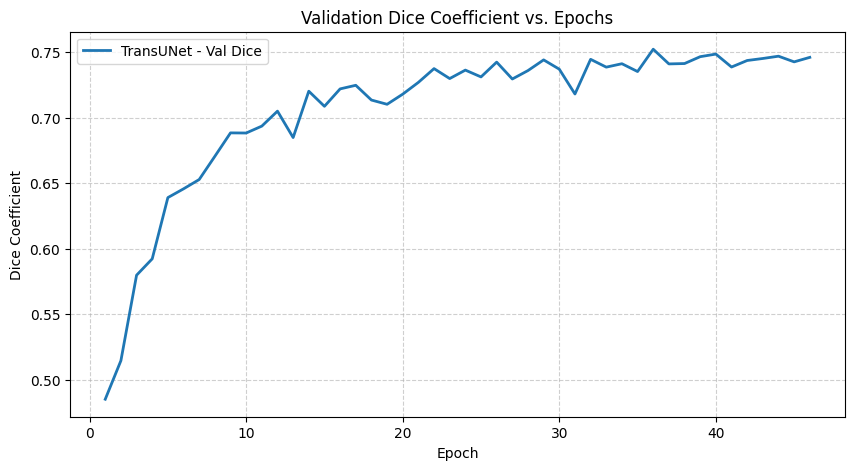

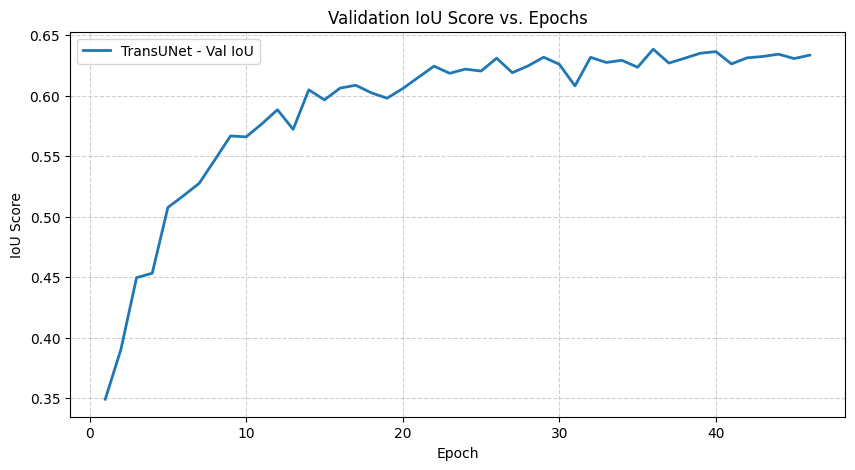


      🔬 GENERATING PREDICTIONS & CONFUSION MATRIX FOR TransUNet 🔬
Plotting 5 examples for TransUNet...


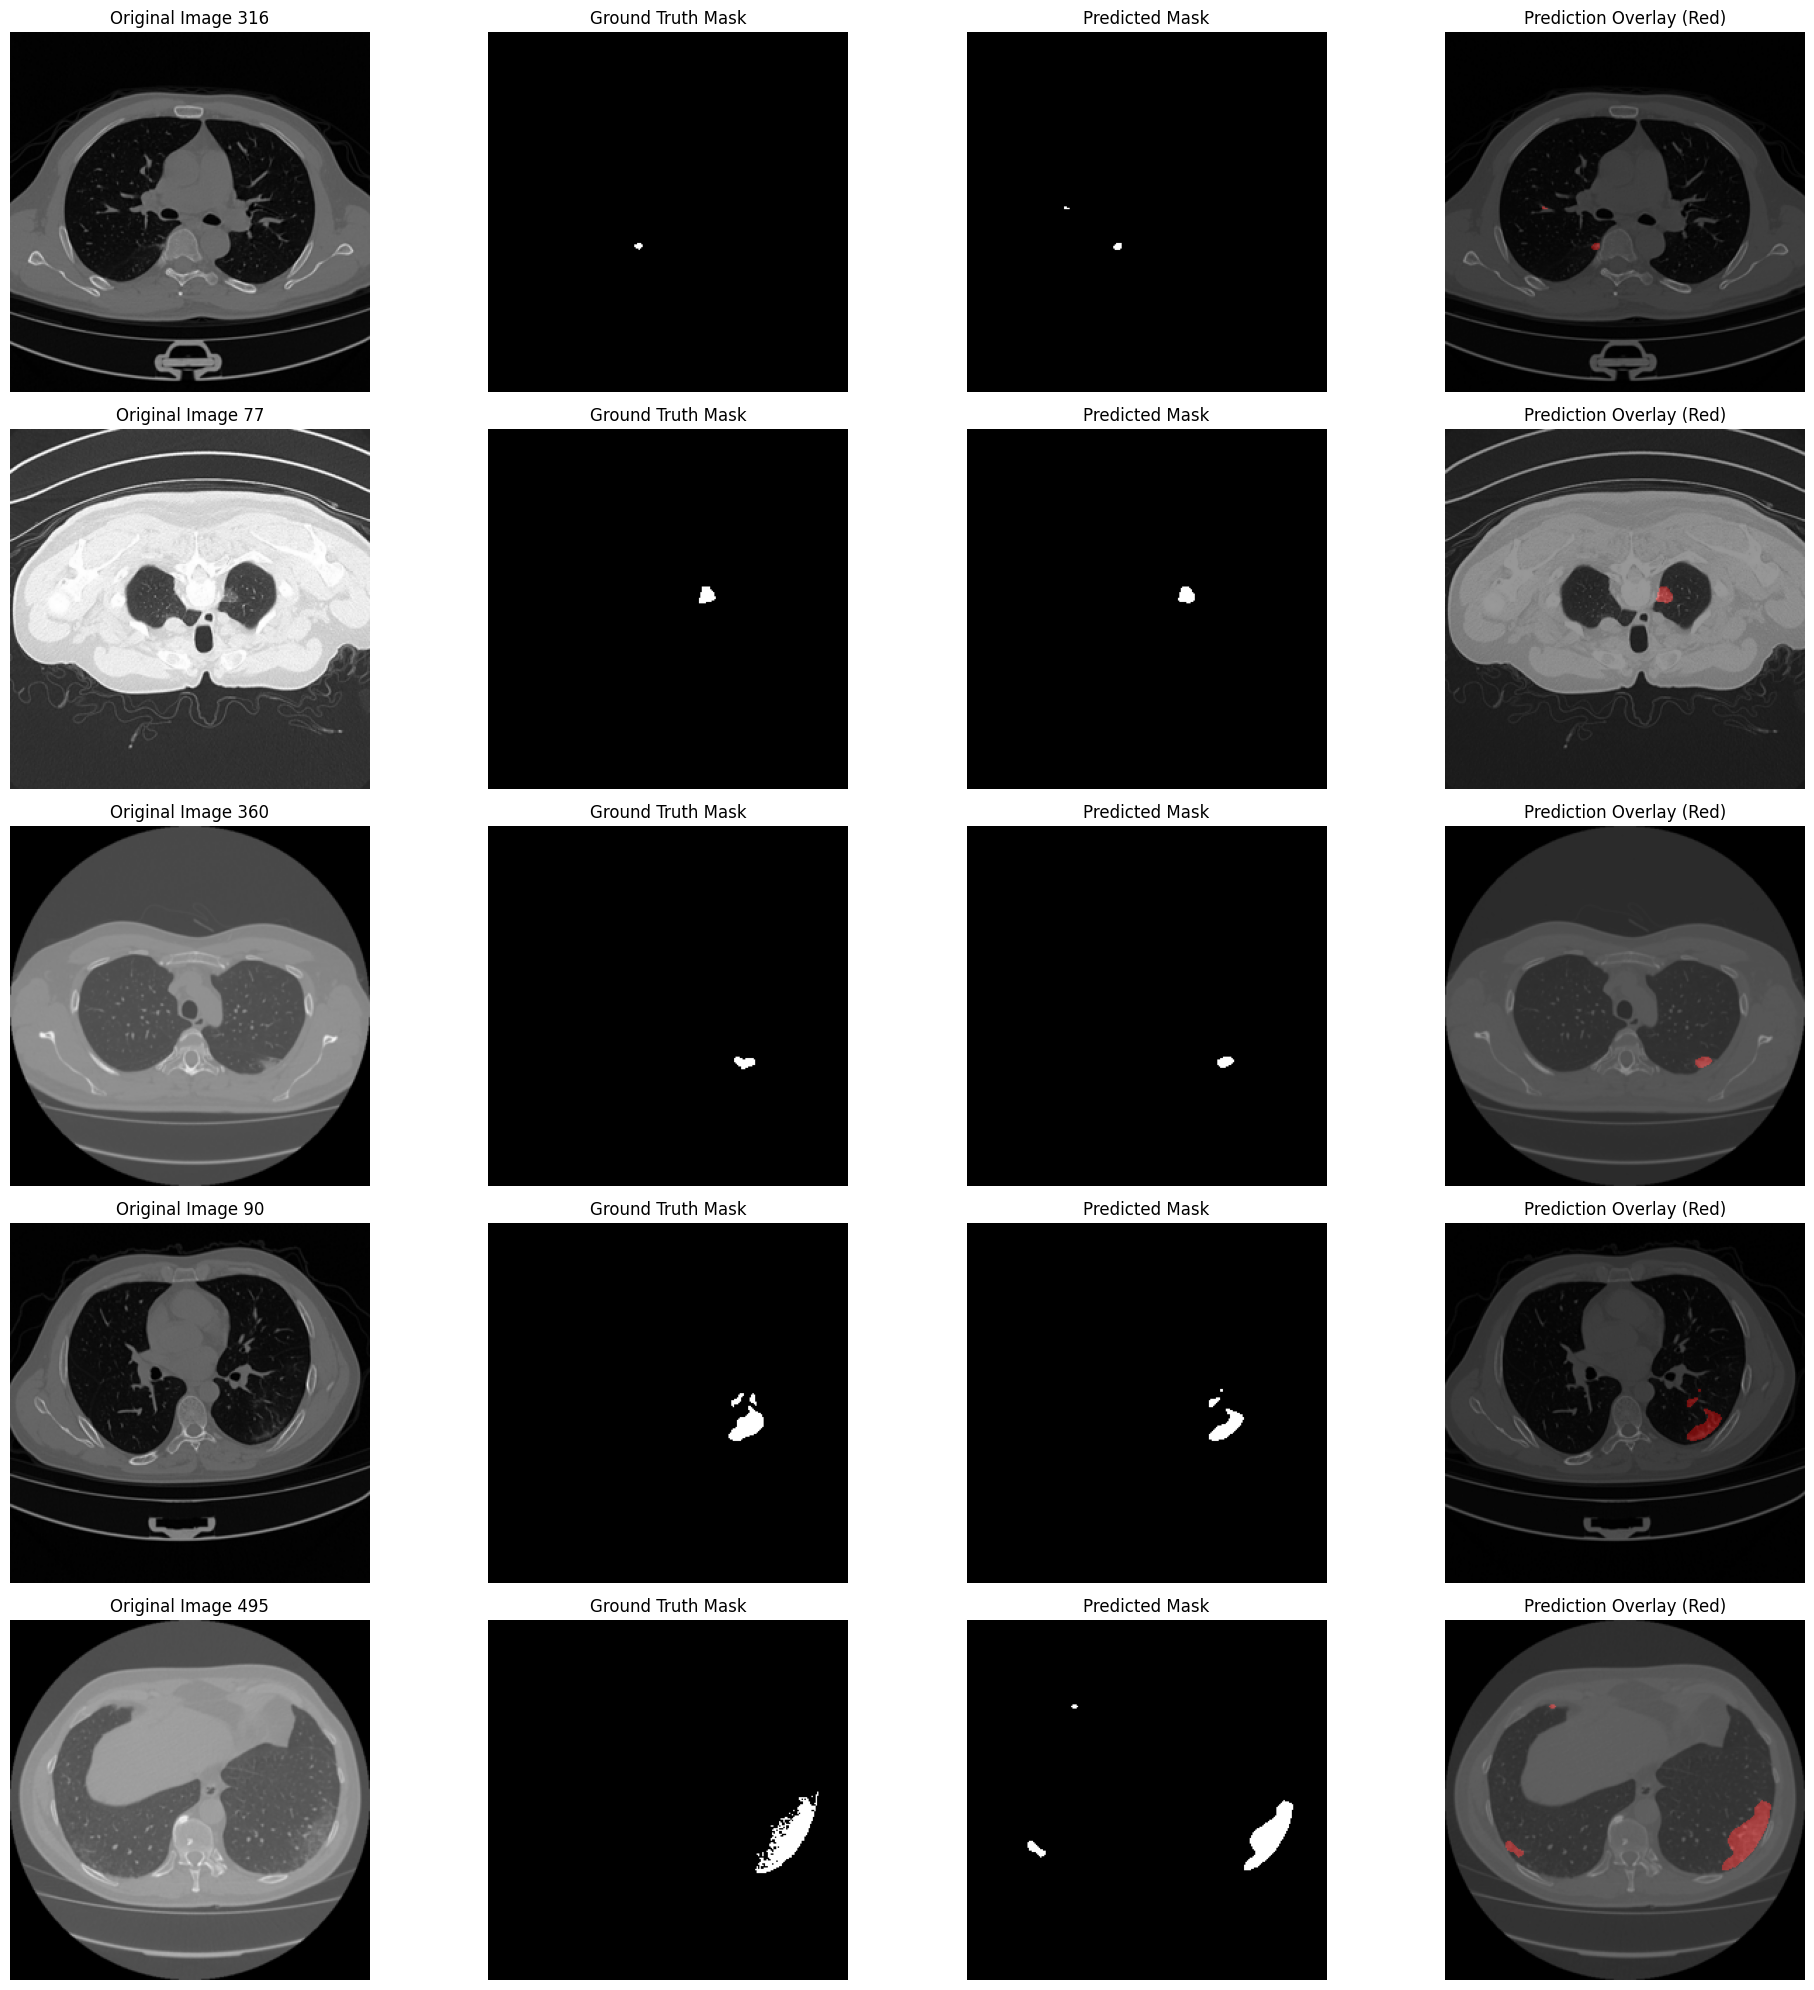

Generating confusion matrix for TransUNet on Validation set...


Generating Confusion Matrix:   0%|          | 0/69 [00:00<?, ?it/s]

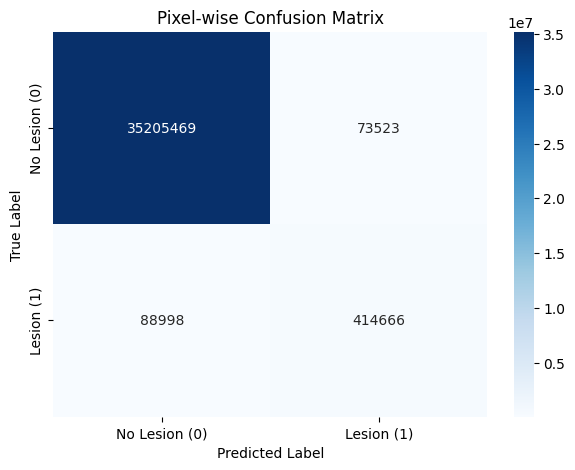


--- Visualization Complete ---


In [61]:
# --- Cell 9: Visualization and Analysis ---

# 1. Install & Import necessary libraries
!pip install -q seaborn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch
import PIL.Image
import os
import gc # For memory cleanup
from tqdm.auto import tqdm # Ensure tqdm is imported

# --- DEFINE CUSTOM VARIABLES (BASED ON YOUR NOTEBOOK) ---
# NOTE: These variables are used by the helper functions below.
# Ensure they match the variables defined in your earlier cells.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "TransUNet"
IMAGE_SIZE = (INPUT_SIZE, INPUT_SIZE) # INPUT_SIZE is defined in Cell 2
val_dataset = val_ds   # Rename from val_ds_other to val_ds if necessary
val_loader = val_loader  # Use the validation dataloader


# --- 2. Plot Training History (Dice) ---

# Reformat the history data for plotting
history_df = pd.DataFrame(hist_trans)
history_df['val_dice'] = history_df['val'].apply(lambda x: x['dice'])
history_df['val_iou'] = history_df['val'].apply(lambda x: x['iou'])


print("\n" + "="*80)
print("                       📊 PLOTTING TRAINING HISTORY 📊")
print("="*80)

# Plot Dice Coefficient
plt.figure(figsize=(10, 5))
plt.plot(history_df['epoch'], history_df['val_dice'], label=f'{MODEL_NAME} - Val Dice', lw=2)
plt.title('Validation Dice Coefficient vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot IoU Score
plt.figure(figsize=(10, 5))
plt.plot(history_df['epoch'], history_df['val_iou'], label=f'{MODEL_NAME} - Val IoU', lw=2)
plt.title('Validation IoU Score vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- 3. Helper Functions for Visualization & Confusion Matrix ---

def plot_predictions(model, dataset, n=5): # Reduced n to 5 for cleaner display
    model.eval()
    plt.figure(figsize=(20, 4 * n))
    
    # We load the best weights before plotting
    model_path = f"{MODEL_NAME}_best.weights.pth"
    model.load_state_dict(torch.load(model_path))

    indices = np.random.choice(len(dataset), n, replace=False)
    
    # Adapt to your dataset structure which requires manual path loading for original image
    # Note: This relies on the dataset object having the image/mask paths accessible.
    # We will approximate by using the index.
    
    for i, idx in enumerate(indices):
        # Retrieve the paths from the original list (assuming it's still in memory)
        # We'll use the original lists (train_val_imgs, etc.) to get the paths.
        # Since 'val_ds' is used, we need its underlying paths. 
        try:
             original_img_path = dataset.images[idx]
             mask_path = dataset.masks[idx]
        except AttributeError:
             print("Warning: Cannot access image/mask paths directly from dataset. Skipping plot.")
             break

        # 1. Get original image for plotting
        original_img = PIL.Image.open(original_img_path).convert("RGB")
        original_img = original_img.resize(IMAGE_SIZE)
        
        # 2. Get ground truth mask
        gt_mask = PIL.Image.open(mask_path).convert("L")
        gt_mask = gt_mask.resize(IMAGE_SIZE, resample=PIL.Image.NEAREST)
        gt_mask_np = np.array(gt_mask) / 255.0
        
        # 3. Get model prediction
        # We use the dataset's __getitem__ to get the preprocessed tensor
        image_tensor, _ = dataset[idx]
        image_tensor = image_tensor.to(DEVICE).unsqueeze(0) # Add batch dim

        with torch.no_grad():
            output = model(image_tensor)
            pred_prob = torch.sigmoid(output)
            # Ensure prediction is resized back to INPUT_SIZE if model output size is different
            pred_prob_resized = F.interpolate(pred_prob, size=IMAGE_SIZE, mode='bilinear', align_corners=False)
            pred_mask = (pred_prob_resized > 0.5).cpu().numpy().squeeze()
            
        # 4. Create overlay
        overlay_mask = np.zeros((*IMAGE_SIZE, 3))
        overlay_mask[pred_mask > 0.5] = [1.0, 0.0, 0.0] # Red channel for prediction

        # 5. Plot
        plt.subplot(n, 4, i * 4 + 1)
        plt.imshow(original_img)
        plt.title(f"Original Image {idx}")
        plt.axis('off')

        plt.subplot(n, 4, i * 4 + 2)
        plt.imshow(gt_mask_np, cmap='gray')
        plt.title("Ground Truth Mask")
        plt.axis('off')

        plt.subplot(n, 4, i * 4 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')

        plt.subplot(n, 4, i * 4 + 4)
        plt.imshow(original_img)
        # Use np.dstack to create the red overlay image
        red_overlay_img = np.zeros((*IMAGE_SIZE, 3))
        red_overlay_img[pred_mask > 0.5] = [1, 0, 0] 
        plt.imshow(red_overlay_img, alpha=0.4) 
        plt.title("Prediction Overlay (Red)")
        plt.axis('off')
            
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_masks = []
    
    # Load the best weights before plotting
    model_path = f"{MODEL_NAME}_best.weights.pth"
    model.load_state_dict(torch.load(model_path))
    
    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Generating Confusion Matrix"):
            images = images.to(device)
            masks_cpu = masks.cpu().numpy()
            
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            
            all_preds.append(preds.flatten())
            all_masks.append(masks_cpu.flatten())
            
    # Concatenate all flattened arrays
    y_true = np.concatenate(all_masks).astype(int)
    y_pred = np.concatenate(all_preds).astype(int)
    
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    # Plot
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Lesion (0)', 'Lesion (1)'],
                yticklabels=['No Lesion (0)', 'Lesion (1)'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Pixel-wise Confusion Matrix')
    plt.show()


# --- 4. Main Execution: Generate Plots for TransUNet ---

print("\n" + "="*80)
print(f"      🔬 GENERATING PREDICTIONS & CONFUSION MATRIX FOR {MODEL_NAME} 🔬")
print("="*80)

# Instantiate the model again (it will be loaded with best weights in the functions)
model = TransUNetLite(pretrained=True).to(DEVICE)
model_path = f"{MODEL_NAME}_best.weights.pth"

# 1. Plot 5 prediction examples
print(f"Plotting 5 examples for {MODEL_NAME}...")
plot_predictions(model, val_ds, n=5) # Use val_ds to match your notebook variables
    
# 2. Plot confusion matrix
print(f"Generating confusion matrix for {MODEL_NAME} on Validation set...")
plot_confusion_matrix(model, val_loader, DEVICE)
    
# Clean up
del model
torch.cuda.empty_cache()
gc.collect()

print("\n--- Visualization Complete ---")

In [62]:
# # Cell 1: Install dependencies (run once)
# !pip install -q timm==0.9.2

# # Imports
# import os
# import glob
# import random
# from pathlib import Path
# from pprint import pprint
# from datetime import datetime

# import numpy as np
# import pandas as pd
# from PIL import Image

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader
# from torchvision import transforms
# import timm

# # Device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Device:", device)
# print("timm version:", timm.__version__)


In [63]:
# # Cell 2: Configuration (edit paths / params)
# INPUT_SIZE = 256               # image H/W
# BATCH_SIZE = 8                 # reduce if memory limited
# NUM_WORKERS = 2
# NUM_CLASSES = 1
# EPOCHS = 8                     # increase for full training
# LR = 1e-4
# SEED = 42

# FRAMES_DIR = "/kaggle/input/covid19-ct-scan-lesion-segmentation-dataset/frames"
# MASKS_DIR  = "/kaggle/input/covid19-ct-scan-lesion-segmentation-dataset/masks"

# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

# # Utility: list files
# frames = sorted(glob.glob(os.path.join(FRAMES_DIR, "bjorke_*.png")))
# masks  = sorted(glob.glob(os.path.join(MASKS_DIR,  "bjorke_*.png")))
# assert len(frames) == len(masks) and len(frames) > 0, "Files missing or mismatch!"
# print("Total samples:", len(frames))


In [64]:
# # Cell 3: Dataset and augmentations
# from torchvision import transforms
# from sklearn.model_selection import train_test_split

# # Custom dataset
# class SegmentationDataset(Dataset):
#     def __init__(self, image_paths, mask_paths, transform_img, transform_mask):
#         self.images = image_paths
#         self.masks = mask_paths
#         self.transform_img = transform_img
#         self.transform_mask = transform_mask

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         img = Image.open(self.images[idx]).convert("RGB")
#         msk = Image.open(self.masks[idx]).convert("L")
#         img = self.transform_img(img)
#         msk = self.transform_mask(msk)
#         msk = (msk > 0.5).float()  # ensure binary
#         return img, msk

# # --- Define transforms for both model types ---
# train_transform_other = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
# ])

# # train_transform_swin = transforms.Compose([
# #     transforms.Resize((224, 224)),
# #     transforms.ToTensor(),
# # ])

# # same for mask transforms
# mask_transform_other = transforms.Compose([
#     transforms.Resize((256, 256), interpolation=Image.NEAREST),
#     transforms.ToTensor(),
# ])

# # mask_transform_swin = transforms.Compose([
# #     transforms.Resize((224, 224), interpolation=Image.NEAREST),
# #     transforms.ToTensor(),
# # ])

# # --- Split train/val ---
# train_imgs, val_imgs, train_masks, val_masks = train_test_split(
#     frames, masks, test_size=0.2, random_state=SEED
# )

# # --- Create two sets of datasets ---
# train_ds_other = SegmentationDataset(train_imgs, train_masks, train_transform_other, mask_transform_other)
# val_ds_other   = SegmentationDataset(val_imgs,   val_masks,   train_transform_other, mask_transform_other)

# # train_ds_swin  = SegmentationDataset(train_imgs, train_masks, train_transform_swin, mask_transform_swin)
# # val_ds_swin    = SegmentationDataset(val_imgs,   val_masks,   train_transform_swin, mask_transform_swin)

# # --- Corresponding dataloaders ---
# train_loader_other = DataLoader(train_ds_other, batch_size=BATCH_SIZE, shuffle=True,
#                                 num_workers=NUM_WORKERS, pin_memory=True)
# val_loader_other   = DataLoader(val_ds_other, batch_size=BATCH_SIZE, shuffle=False,
#                                 num_workers=NUM_WORKERS, pin_memory=True)

# # train_loader_swin = DataLoader(train_ds_swin, batch_size=BATCH_SIZE, shuffle=True,
# #                                num_workers=NUM_WORKERS, pin_memory=True)
# # val_loader_swin   = DataLoader(val_ds_swin, batch_size=BATCH_SIZE, shuffle=False,
# #                                num_workers=NUM_WORKERS, pin_memory=True)

# print("Train batches (TransUNet):", len(train_loader_other))
# #print("Train batches (SwinUNet):", len(train_loader_swin))


In [65]:
# # Cell 4: Loss & metrics
# def dice_coef_tensor(y_true, y_pred, smooth=1e-6):
#     # y_true, y_pred are tensors shaped [B,1,H,W]
#     y_true = y_true.float()
#     y_pred = y_pred.float()
#     inter = (y_true * y_pred).sum(dim=(1,2,3))
#     denom = y_true.sum(dim=(1,2,3)) + y_pred.sum(dim=(1,2,3))
#     dice = (2.0 * inter + smooth) / (denom + smooth)
#     return dice.mean()

# def iou_tensor(y_true, y_pred, smooth=1e-6):
#     y_true = y_true.float()
#     y_pred = y_pred.float()
#     inter = (y_true * y_pred).sum(dim=(1,2,3))
#     union = y_true.sum(dim=(1,2,3)) + y_pred.sum(dim=(1,2,3)) - inter
#     iou = (inter + smooth) / (union + smooth)
#     return iou.mean()

# def sensitivity_tensor(y_true, y_pred):
#     y_true = y_true.float()
#     y_pred = (y_pred > 0.5).float()
#     tp = (y_true * y_pred).sum(dim=(1,2,3))
#     pos = y_true.sum(dim=(1,2,3))
#     return (tp / (pos + 1e-6)).mean()

# def specificity_tensor(y_true, y_pred):
#     y_true = y_true.float()
#     y_pred = (y_pred > 0.5).float()
#     tn = ((1 - y_true) * (1 - y_pred)).sum(dim=(1,2,3))
#     neg = (1 - y_true).sum(dim=(1,2,3))
#     return (tn / (neg + 1e-6)).mean()

# # Hybrid BCE + Dice Loss
# bce_loss = nn.BCEWithLogitsLoss()
# def hybrid_loss_logits(pred_logits, y_true):
#     # pred_logits: raw logits, y_true: {0,1}
#     y_true = y_true.float()
#     bce = bce_loss(pred_logits, y_true)
#     probs = torch.sigmoid(pred_logits)
#     dice = 1.0 - dice_coef_tensor(y_true, probs)
#     return 0.5 * bce + 0.5 * dice


In [66]:
# # Cell 5: Decoder blocks (shared by both models)
# class DecoderBlock(nn.Module):
#     def __init__(self, in_channels, skip_channels, out_channels):
#         super().__init__()
#         self.conv1 = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm2d(out_channels)
#         self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm2d(out_channels)
#         self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
#     def forward(self, x, skip):
#         x = self.up(x)
#         # center-crop/pad skip to match x if needed
#         if skip is not None and skip.shape[-2:] != x.shape[-2:]:
#             skip = F.interpolate(skip, size=x.shape[-2:], mode='bilinear', align_corners=False)
#         x = torch.cat([x, skip], dim=1) if skip is not None else x
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = F.relu(self.bn2(self.conv2(x)))
#         return x


In [67]:
# # Cell 6: TransUNet (lightweight)
# class TransUNetLite(nn.Module):
#     def __init__(self, backbone_name="resnet34", pretrained=True, num_classes=1, embed_dim=512, num_heads=8, transformer_layers=2):
#         super().__init__()
#         # use timm features_only to get multi-scale features
#         self.backbone = timm.create_model(backbone_name, pretrained=pretrained, features_only=True, out_indices=(0,1,2,3))
#         feats = self.backbone.feature_info.channels()  # list of channels for each feature map
#         c1, c2, c3, c4 = feats  # low→high
#         # Project deepest feature to embed_dim for transformer
#         self.project = nn.Conv2d(c4, embed_dim, kernel_size=1)
#         # simple transformer encoder on flattened patches of deepest features
#         encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=embed_dim*2)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)
#         # decoder blocks: we will decode from embed_dim -> c3 -> c2 -> c1
#         self.dec3 = DecoderBlock(in_channels=embed_dim, skip_channels=c3, out_channels=256)
#         self.dec2 = DecoderBlock(in_channels=256, skip_channels=c2, out_channels=128)
#         self.dec1 = DecoderBlock(in_channels=128, skip_channels=c1, out_channels=64)
#         self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)
#     def forward(self, x):
#         # backbone features: list [f1,f2,f3,f4] where f4 is deepest
#         feats = self.backbone(x)
#         f1, f2, f3, f4 = feats
#         # project
#         p = self.project(f4)                          # shape [B, E, Hf, Wf]
#         B, E, Hf, Wf = p.shape
#         # flatten patches for transformer: seq_len = Hf*Wf
#         seq = p.flatten(2).transpose(1,2)             # [B, seq, E]
#         seq = self.transformer(seq)                   # [B, seq, E]
#         # reshape back
#         p2 = seq.transpose(1,2).view(B, E, Hf, Wf)    # [B, E, Hf, Wf]
#         # decode
#         d3 = self.dec3(p2, f3)                        # up -> combine with f3
#         d2 = self.dec2(d3, f2)
#         d1 = self.dec1(d2, f1)
#         out = self.final_conv(d1)
#         out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)
#         return out

# # sanity instantiate
# _model = TransUNetLite(pretrained=True).to(device)
# print("TransUNetLite parameters:", sum(p.numel() for p in _model.parameters())/1e6, "M")


In [68]:
# # Cell 7: Swin-UNet style model using timm Swin backbone features
# class SwinUNetLite(nn.Module):
#     def __init__(self, backbone_name="swin_tiny_patch4_window7_224", pretrained=True, num_classes=1):
#         super().__init__()
#         # tell timm we will use 256x256 images
#         self.backbone = timm.create_model(
#             backbone_name,
#             pretrained=pretrained,
#             features_only=True,
#             out_indices=(0,1,2,3),
#             img_size=256   # <-- this line is key
#         )
#         feats = self.backbone.feature_info.channels()
#         c1, c2, c3, c4 = feats
#         self.reduce = nn.Conv2d(c4, 256, kernel_size=1)
#         self.dec3 = DecoderBlock(in_channels=256, skip_channels=c3, out_channels=256)
#         self.dec2 = DecoderBlock(in_channels=256, skip_channels=c2, out_channels=128)
#         self.dec1 = DecoderBlock(in_channels=128, skip_channels=c1, out_channels=64)
#         self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)
#     def forward(self, x):
#         f1, f2, f3, f4 = self.backbone(x)
#         p = self.reduce(f4)
#         d3 = self.dec3(p, f3)
#         d2 = self.dec2(d3, f2)
#         d1 = self.dec1(d2, f1)
#         out = self.final_conv(d1)
#         out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)
#         return out

# # sanity instantiate
# _model2 = SwinUNetLite(pretrained=True).to(device)
# print("SwinUNetLite parameters:", sum(p.numel() for p in _model2.parameters())/1e6, "M")


In [69]:
# # Cell 8: Training utilities and run
# from torch.optim import Adam
# from tqdm.auto import tqdm

# def run_epoch(model, loader, optimizer=None, train=True):
#     if train:
#         model.train()
#     else:
#         model.eval()
#     losses = []
#     dices = []
#     ious = []
#     sens = []
#     specs = []
#     for imgs, masks in loader:
#         imgs = imgs.to(device); masks = masks.to(device)
#         if train:
#             optimizer.zero_grad()
#         logits = model(imgs)
#         # ensure logits shape matches masks: [B,1,H,W]
#         if logits.shape[1] != masks.shape[1]:
#             # project channels if needed
#             logits = logits[:, :masks.shape[1], ...]
#         loss = hybrid_loss_logits(logits, masks)
#         probs = torch.sigmoid(logits)
#         # metrics (use threshold 0.5)
#         with torch.no_grad():
#             d = dice_coef_tensor(masks, probs).item()
#             i = iou_tensor(masks, probs).item()
#             se = sensitivity_tensor(masks, probs).item()
#             sp = specificity_tensor(masks, probs).item()
#         losses.append(loss.item()); dices.append(d); ious.append(i); sens.append(se); specs.append(sp)
#         if train:
#             loss.backward()
#             optimizer.step()
#     return {
#         "loss": float(np.mean(losses)),
#         "dice": float(np.mean(dices)),
#         "iou": float(np.mean(ious)),
#         "sens": float(np.mean(sens)),
#         "spec": float(np.mean(specs))
#     }

# def train_model(model, name, epochs=EPOCHS):
#     model = model.to(device)
#     optimizer = Adam(model.parameters(), lr=LR)
#     best_dice = -1.0
#     history = []
#     for epoch in range(1, epochs+1):
#         tr = run_epoch(model, train_loader, optimizer, train=True)
#         val = run_epoch(model, val_loader, optimizer=None, train=False)
#         history.append({"epoch": epoch, "train": tr, "val": val})
#         print(f"[{name}] Epoch {epoch}/{epochs} - train loss {tr['loss']:.4f} dice {tr['dice']:.4f} | val loss {val['loss']:.4f} dice {val['dice']:.4f}")
#         # checkpoint on val dice
#         if val['dice'] > best_dice:
#             best_dice = val['dice']
#             torch.save(model.state_dict(), f"{name}_best.weights.pth")
#     return history, best_dice

# # Instantiate fresh models for training
# trans_model = TransUNetLite(pretrained=True).to(device)
# #swin_model  = SwinUNetLite(pretrained=True).to(device)
# # Train TransUNet (256×256)
# hist_trans, best_trans = train_model(
#     trans_model, "TransUNet", epochs=EPOCHS//2 or 1
# )

# # Train SwinUNet (224×224)
# # temporarily override global train/val loader variables
# # train_loader, val_loader = train_loader_swin, val_loader_swin
# # hist_swin, best_swin = train_model(
# #     swin_model, "SwinUNet", epochs=EPOCHS//2 or 1
# # )

# # Summarize
# results = [
#     {"Model": "TransUNet", "BestValDice": best_trans}
#     #{"Model": "SwinUNet",  "BestValDice": best_swin}
# ]
# df = pd.DataFrame(results).set_index('Model')
# print("\nComparison:")
# print(df.round(4).to_markdown())


In [70]:
# # --- Cell 5: Train Both Models ---
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
# import pandas as pd

# def train_and_evaluate(builder, name, epochs=50):
#     print(f"\n{'='*20} TRAINING {name} {'='*20}")
#     ckpt = ModelCheckpoint(f'{name}_best.h5', monitor='val_dice_coef', mode='max',
#                            save_best_only=True, save_weights_only=True, verbose=1)
#     model = builder()
#     hist = model.fit(
#         train_gen, steps_per_epoch=len(train_gen),
#         epochs=epochs, validation_data=val_gen, validation_steps=len(val_gen),
#         callbacks=[EarlyStopping(patience=10, restore_best_weights=True),
#                    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7), ckpt],
#         verbose=1
#     )
#     model.load_weights(f'{name}_best.h5')
#     res = model.evaluate(val_gen, verbose=0)
#     return { 'Model': name, 'Loss': res[0], 'IoU': res[1], 'Dice': res[2],
#              'Sens': res[3], 'Spec': res[4], 'Acc': res[5] }, model, hist

# # Run
# experiments = [(build_trans_unet, "TransUNet"), (build_swin_unet, "SwinUNet")]
# results = []
# for builder, name in experiments:
#     res, _, _ = train_and_evaluate(builder, name, epochs=50)
#     results.append(res)

# df = pd.DataFrame(results).set_index('Model')
# print("\nFINAL RESULTS:")
# print(df.round(4).to_markdown())

In [71]:
# !pip install timm segmentation-models-pytorch albumentations==1.4.3


In [72]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, Dataset
# import torchvision.transforms as transforms
# import torchvision
# import timm
# import numpy as np
# import cv2
# from tqdm import tqdm
# import os
# from PIL import Image
# import matplotlib.pyplot as plt
# import segmentation_models_pytorch as smp

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)


In [73]:
# class SegmentationDataset(Dataset):
#     def __init__(self, img_dir, mask_dir, transform=None):
#         self.img_dir = img_dir
#         self.mask_dir = mask_dir
#         self.transform = transform
#         self.images = sorted(os.listdir(img_dir))

#     def __len__(self):
#         return len(self.images)

#     def __getitem__(self, idx):
#         img_path = os.path.join(self.img_dir, self.images[idx])
#         mask_path = os.path.join(self.mask_dir, self.images[idx])
#         image = np.array(Image.open(img_path).convert("RGB"))
#         mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
#         mask = np.expand_dims(mask, axis=0) / 255.0

#         if self.transform:
#             image = self.transform(image)

#         return image, torch.tensor(mask, dtype=torch.float32)


In [74]:
# train_transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
# ])

# # Replace these with your dataset paths
# train_img_dir = "/kaggle/input/your-dataset/train/images"
# train_mask_dir = "/kaggle/input/your-dataset/train/masks"
# val_img_dir = "/kaggle/input/your-dataset/val/images"
# val_mask_dir = "/kaggle/input/your-dataset/val/masks"

# train_dataset = SegmentationDataset(train_img_dir, train_mask_dir, transform=train_transform)
# val_dataset = SegmentationDataset(val_img_dir, val_mask_dir, transform=train_transform)

# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

# print("Train batches:", len(train_loader), "Validation batches:", len(val_loader))


In [75]:
# class TransUNet(nn.Module):
#     def __init__(self, img_size=256, num_classes=1, vit_name='vit_base_patch16_224', pretrained=True):
#         super().__init__()
#         # CNN encoder (ResNet)
#         self.encoder = timm.create_model("resnet50", pretrained=pretrained, features_only=True, out_indices=(1, 2, 3, 4))
#         feats = self.encoder.feature_info.channels()
#         self.c1, self.c2, self.c3, self.c4 = feats

#         # ViT bottleneck
#         self.vit = timm.create_model(vit_name, pretrained=pretrained, num_classes=0)
#         self.vit.patch_embed.proj = nn.Conv2d(self.c4, self.vit.embed_dim, kernel_size=1)

#         # UNet decoder
#         self.up4 = self._up_block(self.vit.embed_dim, self.c3, 256)
#         self.up3 = self._up_block(256, self.c2, 128)
#         self.up2 = self._up_block(128, self.c1, 64)
#         self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

#     def _up_block(self, in_ch, skip_ch, out_ch):
#         return nn.Sequential(
#             nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(out_ch, out_ch, 3, padding=1),
#             nn.BatchNorm2d(out_ch),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x):
#         f1, f2, f3, f4 = self.encoder(x)
#         b = self.vit.forward_features(f4)
#         b = F.interpolate(b, size=f4.shape[2:], mode='bilinear', align_corners=False)
#         d4 = self.up4(torch.cat([b, f3], dim=1))
#         d3 = self.up3(torch.cat([d4, f2], dim=1))
#         d2 = self.up2(torch.cat([d3, f1], dim=1))
#         out = self.final_conv(d2)
#         out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)
#         return out


In [76]:
# model = TransUNet().to(device)
# criterion = smp.losses.DiceLoss(mode='binary')
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# print("Model parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")


In [77]:
# def train_one_epoch(model, loader, optimizer, criterion):
#     model.train()
#     epoch_loss = 0
#     for imgs, masks in tqdm(loader):
#         imgs, masks = imgs.to(device), masks.to(device)
#         preds = model(imgs)
#         loss = criterion(preds, masks)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#     return epoch_loss / len(loader)

# def evaluate(model, loader, criterion):
#     model.eval()
#     val_loss = 0
#     with torch.no_grad():
#         for imgs, masks in loader:
#             imgs, masks = imgs.to(device), masks.to(device)
#             preds = model(imgs)
#             val_loss += criterion(preds, masks).item()
#     return val_loss / len(loader)


In [78]:
# EPOCHS = 10
# for epoch in range(EPOCHS):
#     train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
#     val_loss = evaluate(model, val_loader, criterion)
#     print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


In [79]:
# model.eval()
# imgs, masks = next(iter(val_loader))
# imgs = imgs.to(device)
# with torch.no_grad():
#     preds = torch.sigmoid(model(imgs))

# plt.figure(figsize=(12, 6))
# for i in range(3):
#     plt.subplot(3, 3, i*3+1)
#     plt.imshow(imgs[i].permute(1,2,0).cpu())
#     plt.title("Image")
#     plt.axis("off")

#     plt.subplot(3, 3, i*3+2)
#     plt.imshow(masks[i][0].cpu(), cmap='gray')
#     plt.title("Mask")
#     plt.axis("off")

#     plt.subplot(3, 3, i*3+3)
#     plt.imshow(preds[i][0].cpu() > 0.5, cmap='gray')
#     plt.title("Predicted")
#     plt.axis("off")
# plt.show()
